# 04 — Multi-Category Liver Pathology Models

For every liver pathology category with sufficient samples, run blood-based CV.

In [1]:
import numpy as np
import pandas as pd
from collections import Counter
from joblib import Parallel, delayed

from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache
from gtex_biomarkers.models import run_cv, make_lr_pipeline
from gtex_biomarkers.evaluation import plot_roc_grid, plot_pr_grid, plot_cm_grid, plot_boxplot_grid

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, _ = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Discover Eligible Categories

In [2]:
liver_imp = pd.read_csv(Config.PROCESSED_DIR / "liver_pathology_labels_imputed.csv")

cat_counts = Counter()
for val in liver_imp["Pathology.Categories.Final"].dropna():
    for c in val.split(", "):
        cat_counts[c.strip()] += 1

eligible_cats = sorted(c for c, n in cat_counts.items()
                       if n >= Config.SAMPLE_THRESHOLD_LIVER
                       and c not in Config.NORMAL_LABELS)
print(f"Eligible categories: {eligible_cats}")

Eligible categories: ['atrophy', 'cirrhosis', 'congestion', 'fibrosis', 'hemorrhage', 'hepatitis', 'inflammation', 'necrosis', 'nodularity', 'steatosis']


## Build Donor Labels & Run Parallel CV

In [3]:
# Donor-level labels
liver_known = liver_imp[liver_imp["Pathology.Categories.Final"].notna()].copy()
all_donors = liver_imp["SUBJID"].unique()

donor_labels = {}
for cat in eligible_cats:
    has_cat = liver_known["Pathology.Categories.Final"].str.contains(cat, case=False).astype(int)
    donor_labels[cat] = has_cat.groupby(liver_known["SUBJID"]).max()

# Run each category (parallelized)
def _run_cat(cat):
    y_cat = blood_subjid.map(donor_labels[cat])
    keep = y_cat.notna()
    res = run_cv(X_wb.loc[keep], y_cat.loc[keep].astype(int),
                 blood_subjid.loc[keep].astype(str), make_lr_pipeline)
    return (cat, res)

results_list = Parallel(n_jobs=-1, verbose=10)(
    delayed(_run_cat)(cat) for cat in eligible_cats
)
model_results = dict(results_list)

for cat, res in model_results.items():
    print(f"  {cat:20s}  AUC = {res['mean_auc']:.3f} ± {res['std_auc']:.3f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  6.2min remaining: 14.5min
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:  6.2min remaining:  6.2min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  6.2min remaining:  2.7min


  atrophy               AUC = 0.785 ± 0.150
  cirrhosis             AUC = 0.798 ± 0.095
  congestion            AUC = 0.618 ± 0.017
  fibrosis              AUC = 0.444 ± 0.099
  hemorrhage            AUC = 0.576 ± 0.062
  hepatitis             AUC = 0.536 ± 0.061
  inflammation          AUC = 0.469 ± 0.059
  necrosis              AUC = 0.538 ± 0.121
  nodularity            AUC = 0.839 ± 0.069
  steatosis             AUC = 0.519 ± 0.043


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  8.9min finished


## Evaluation Plots

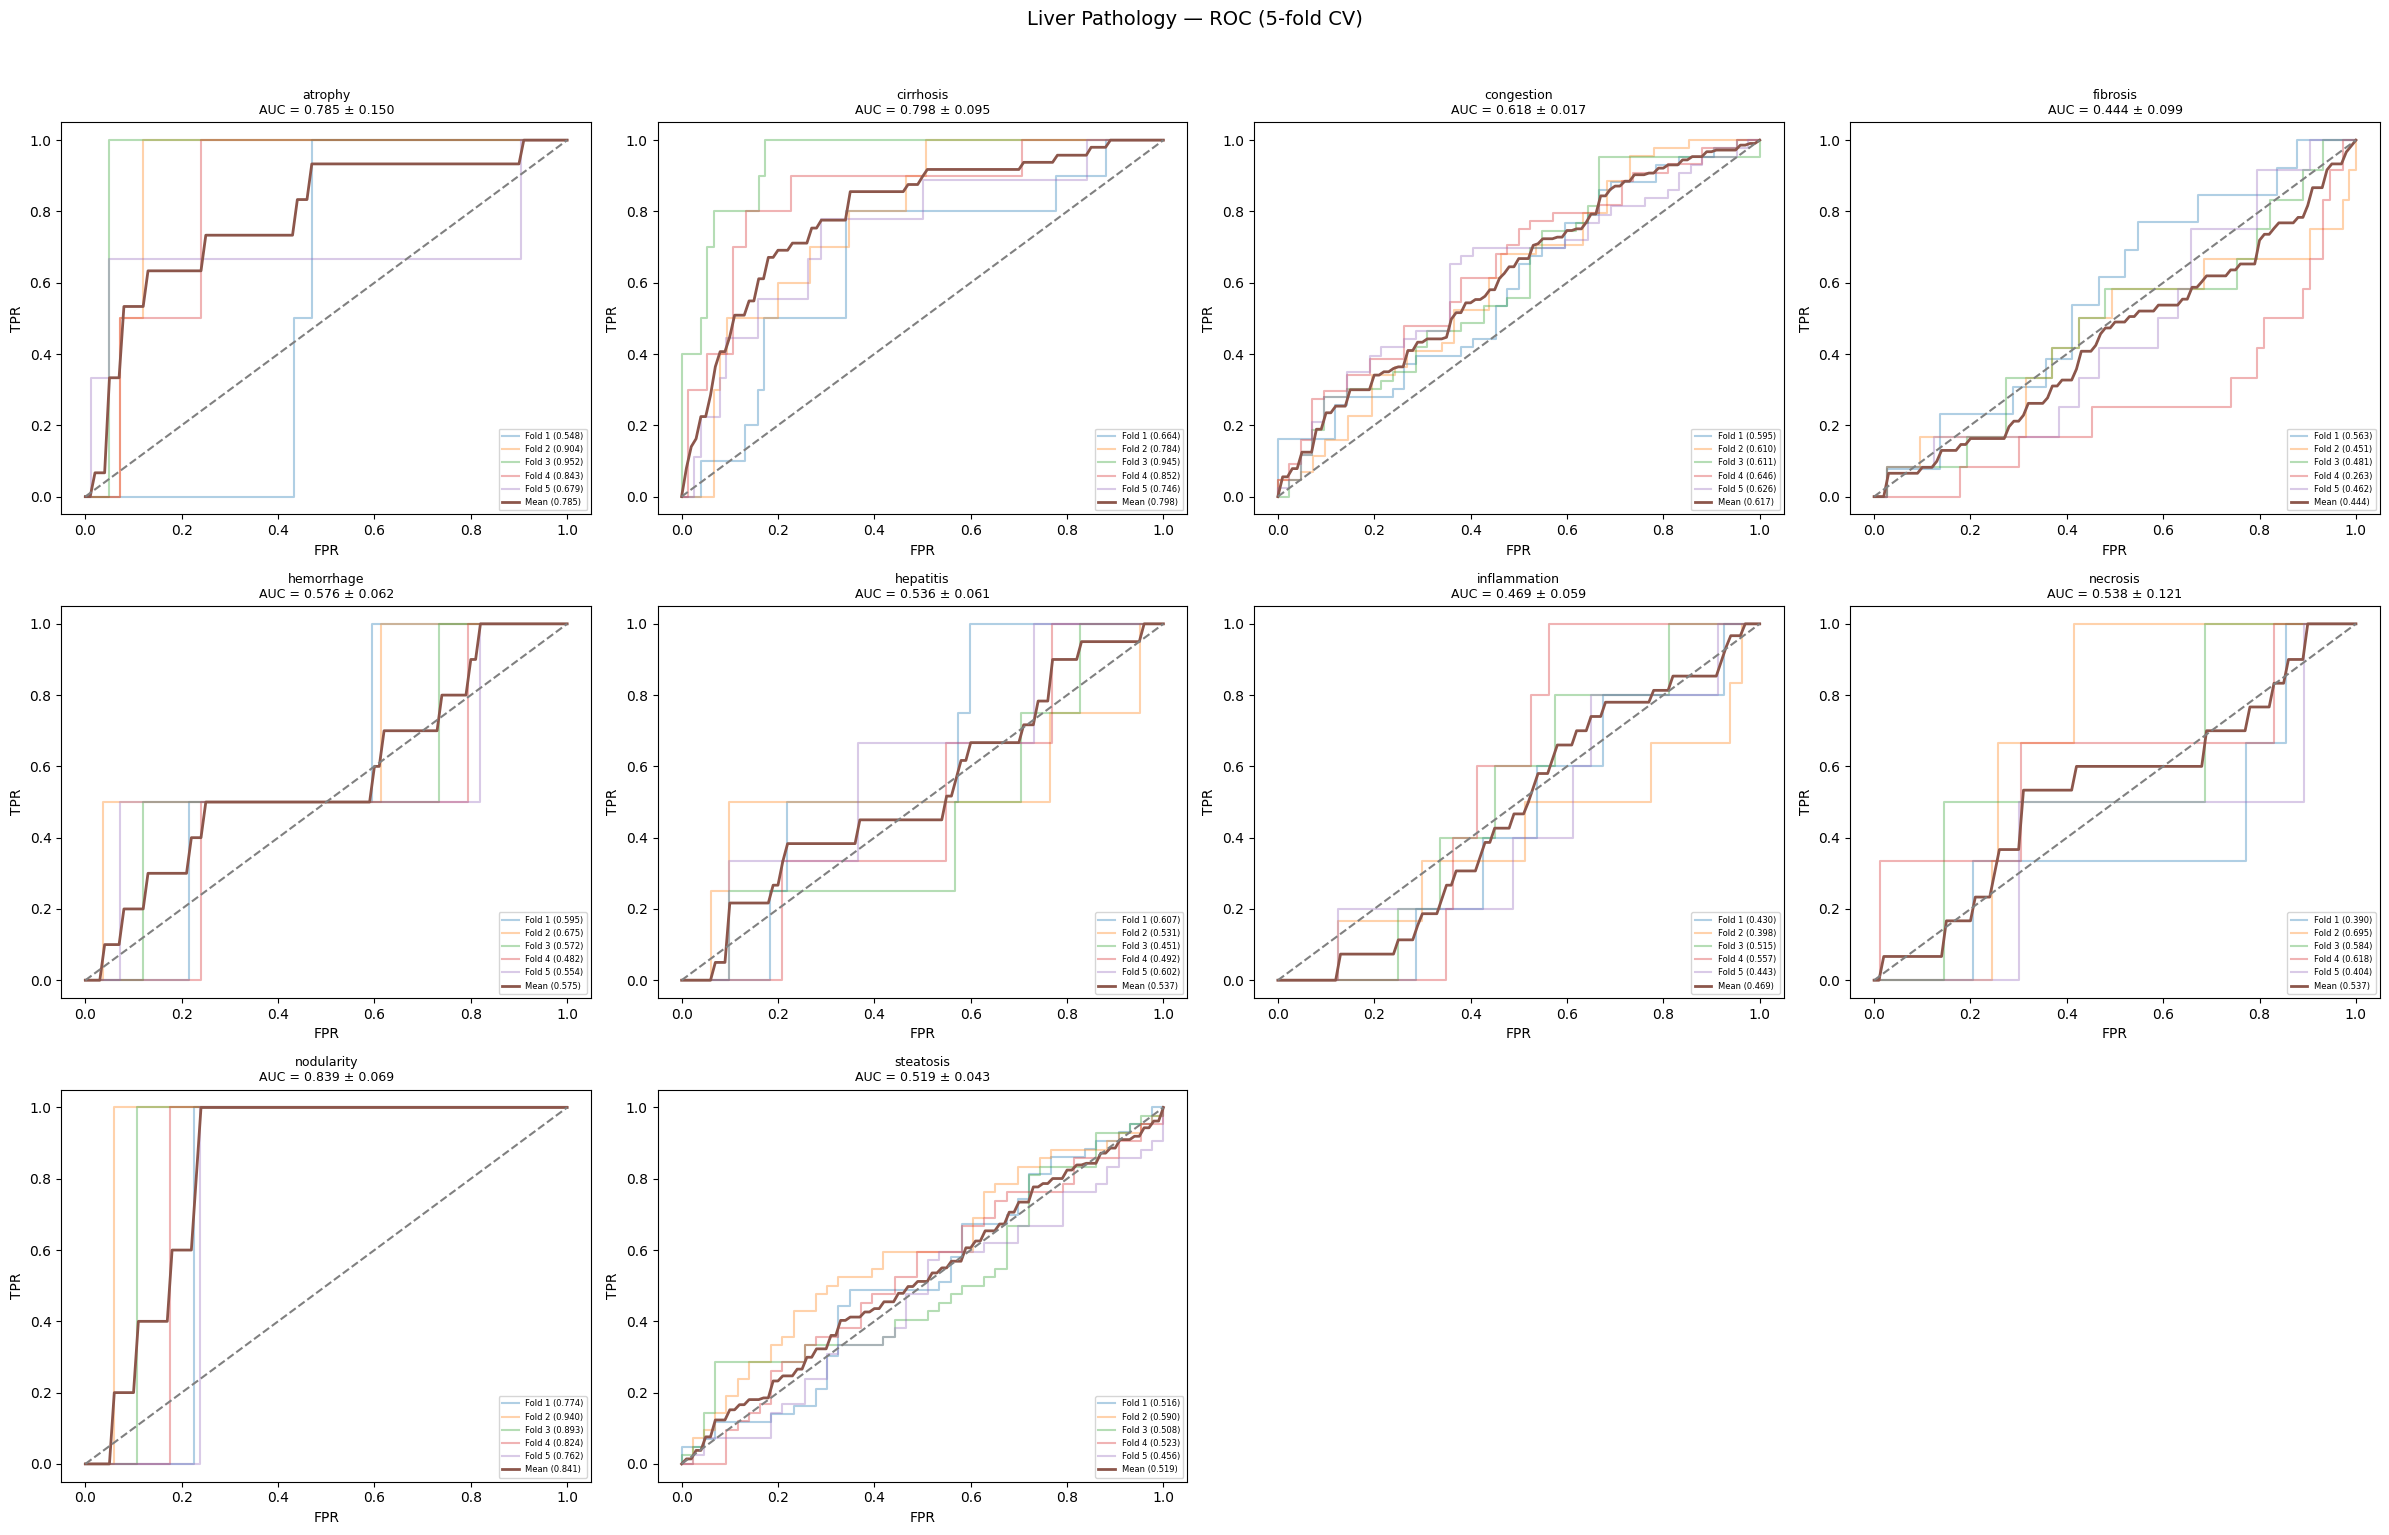

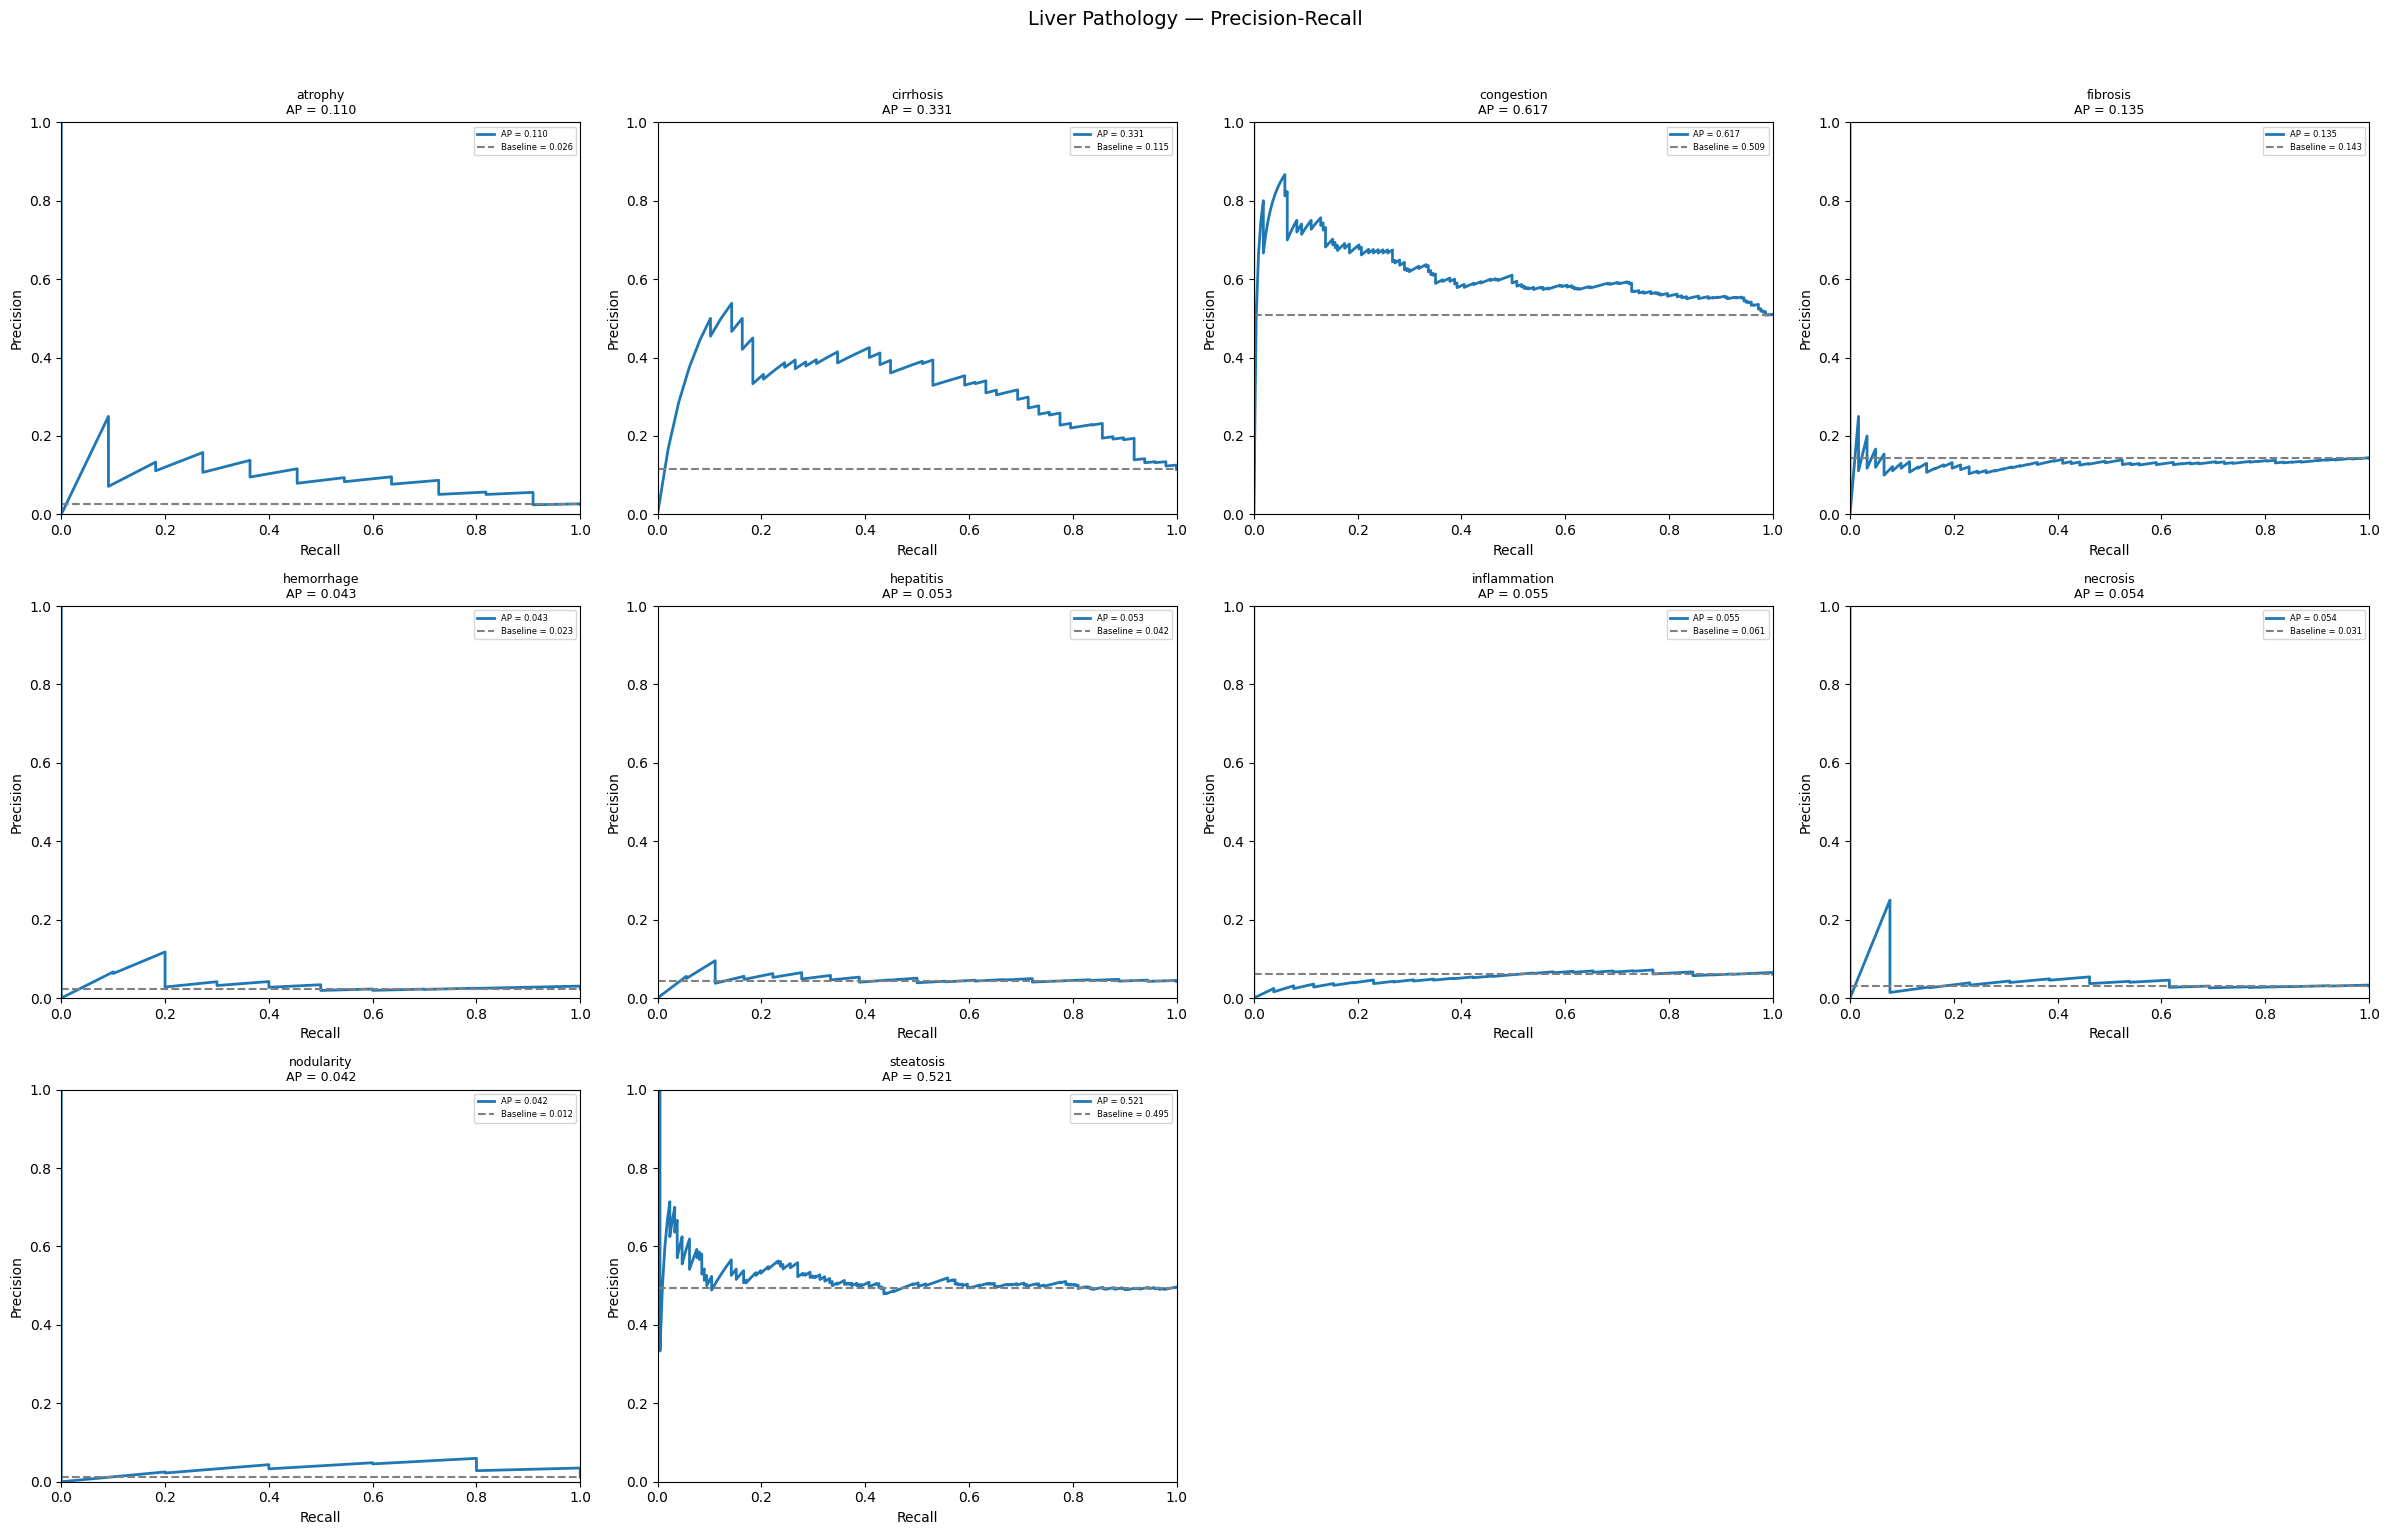

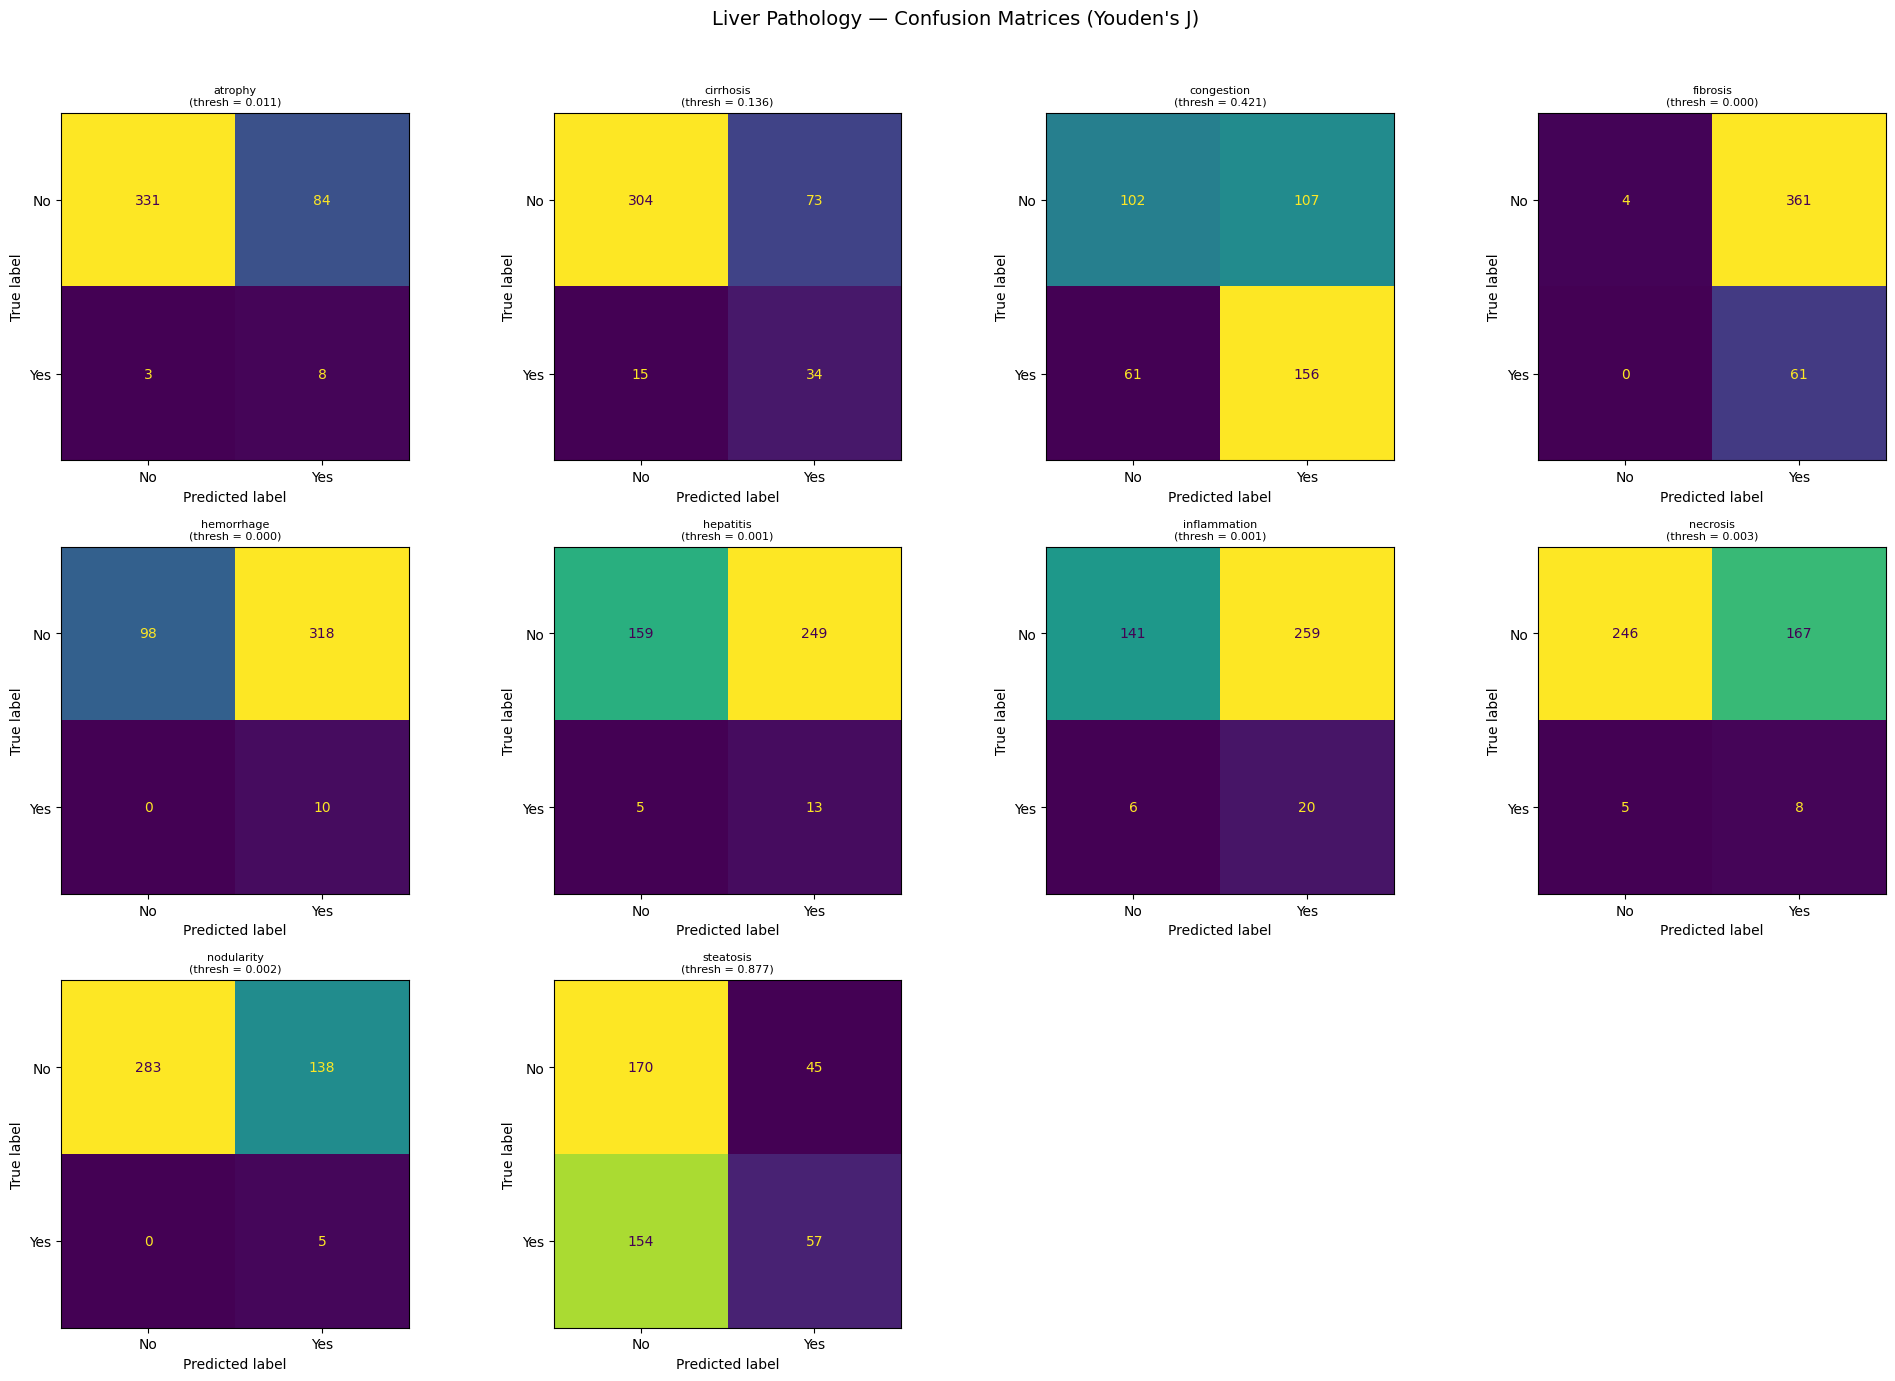

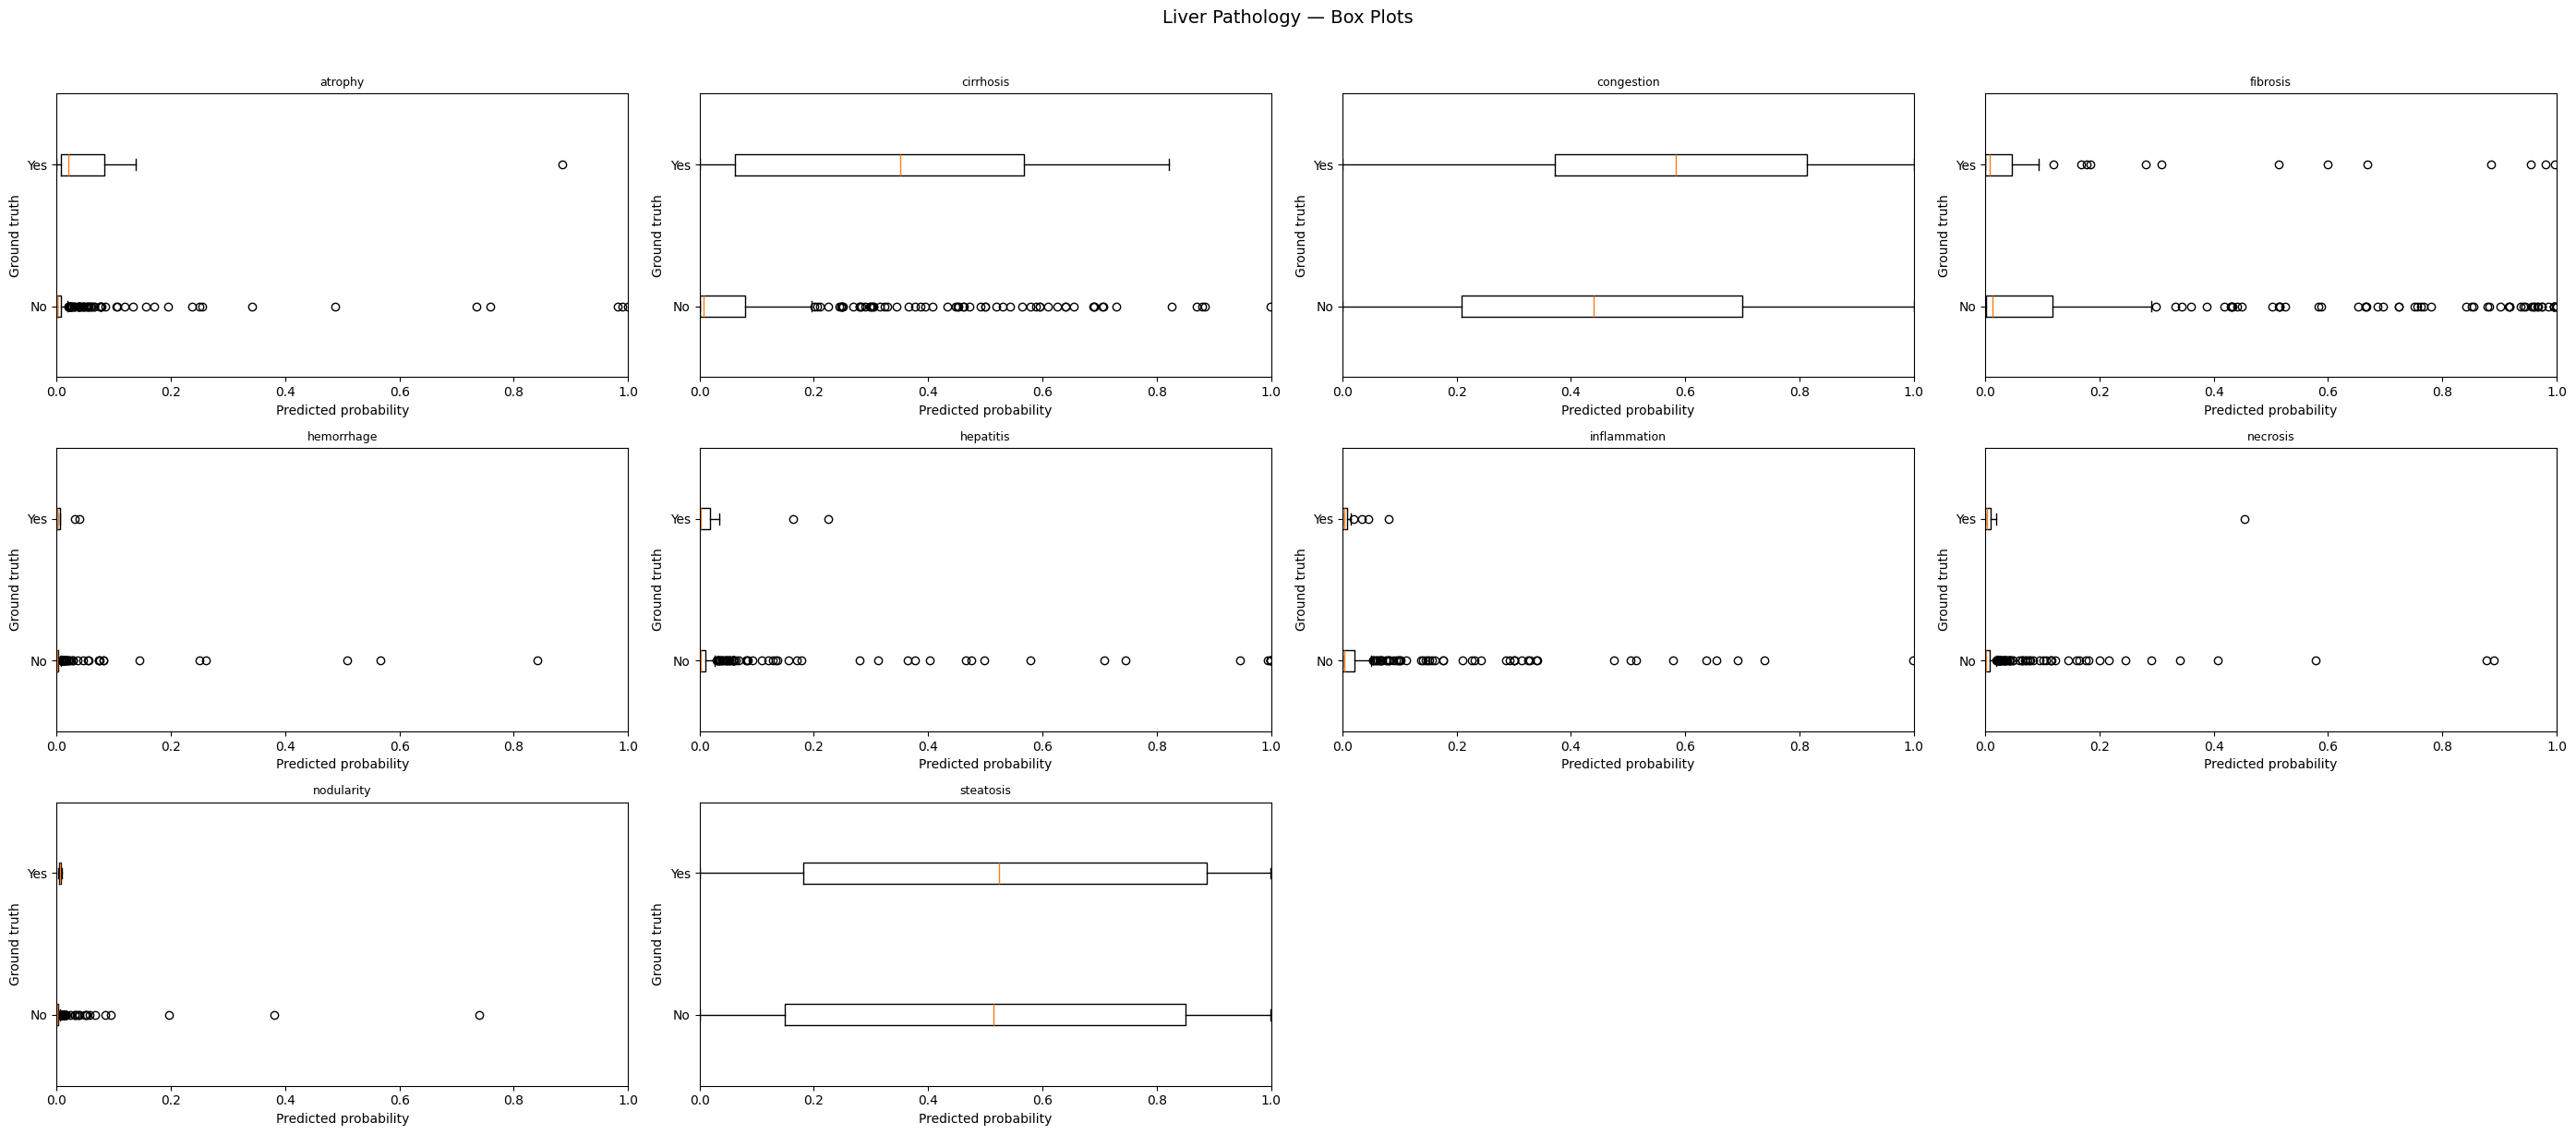

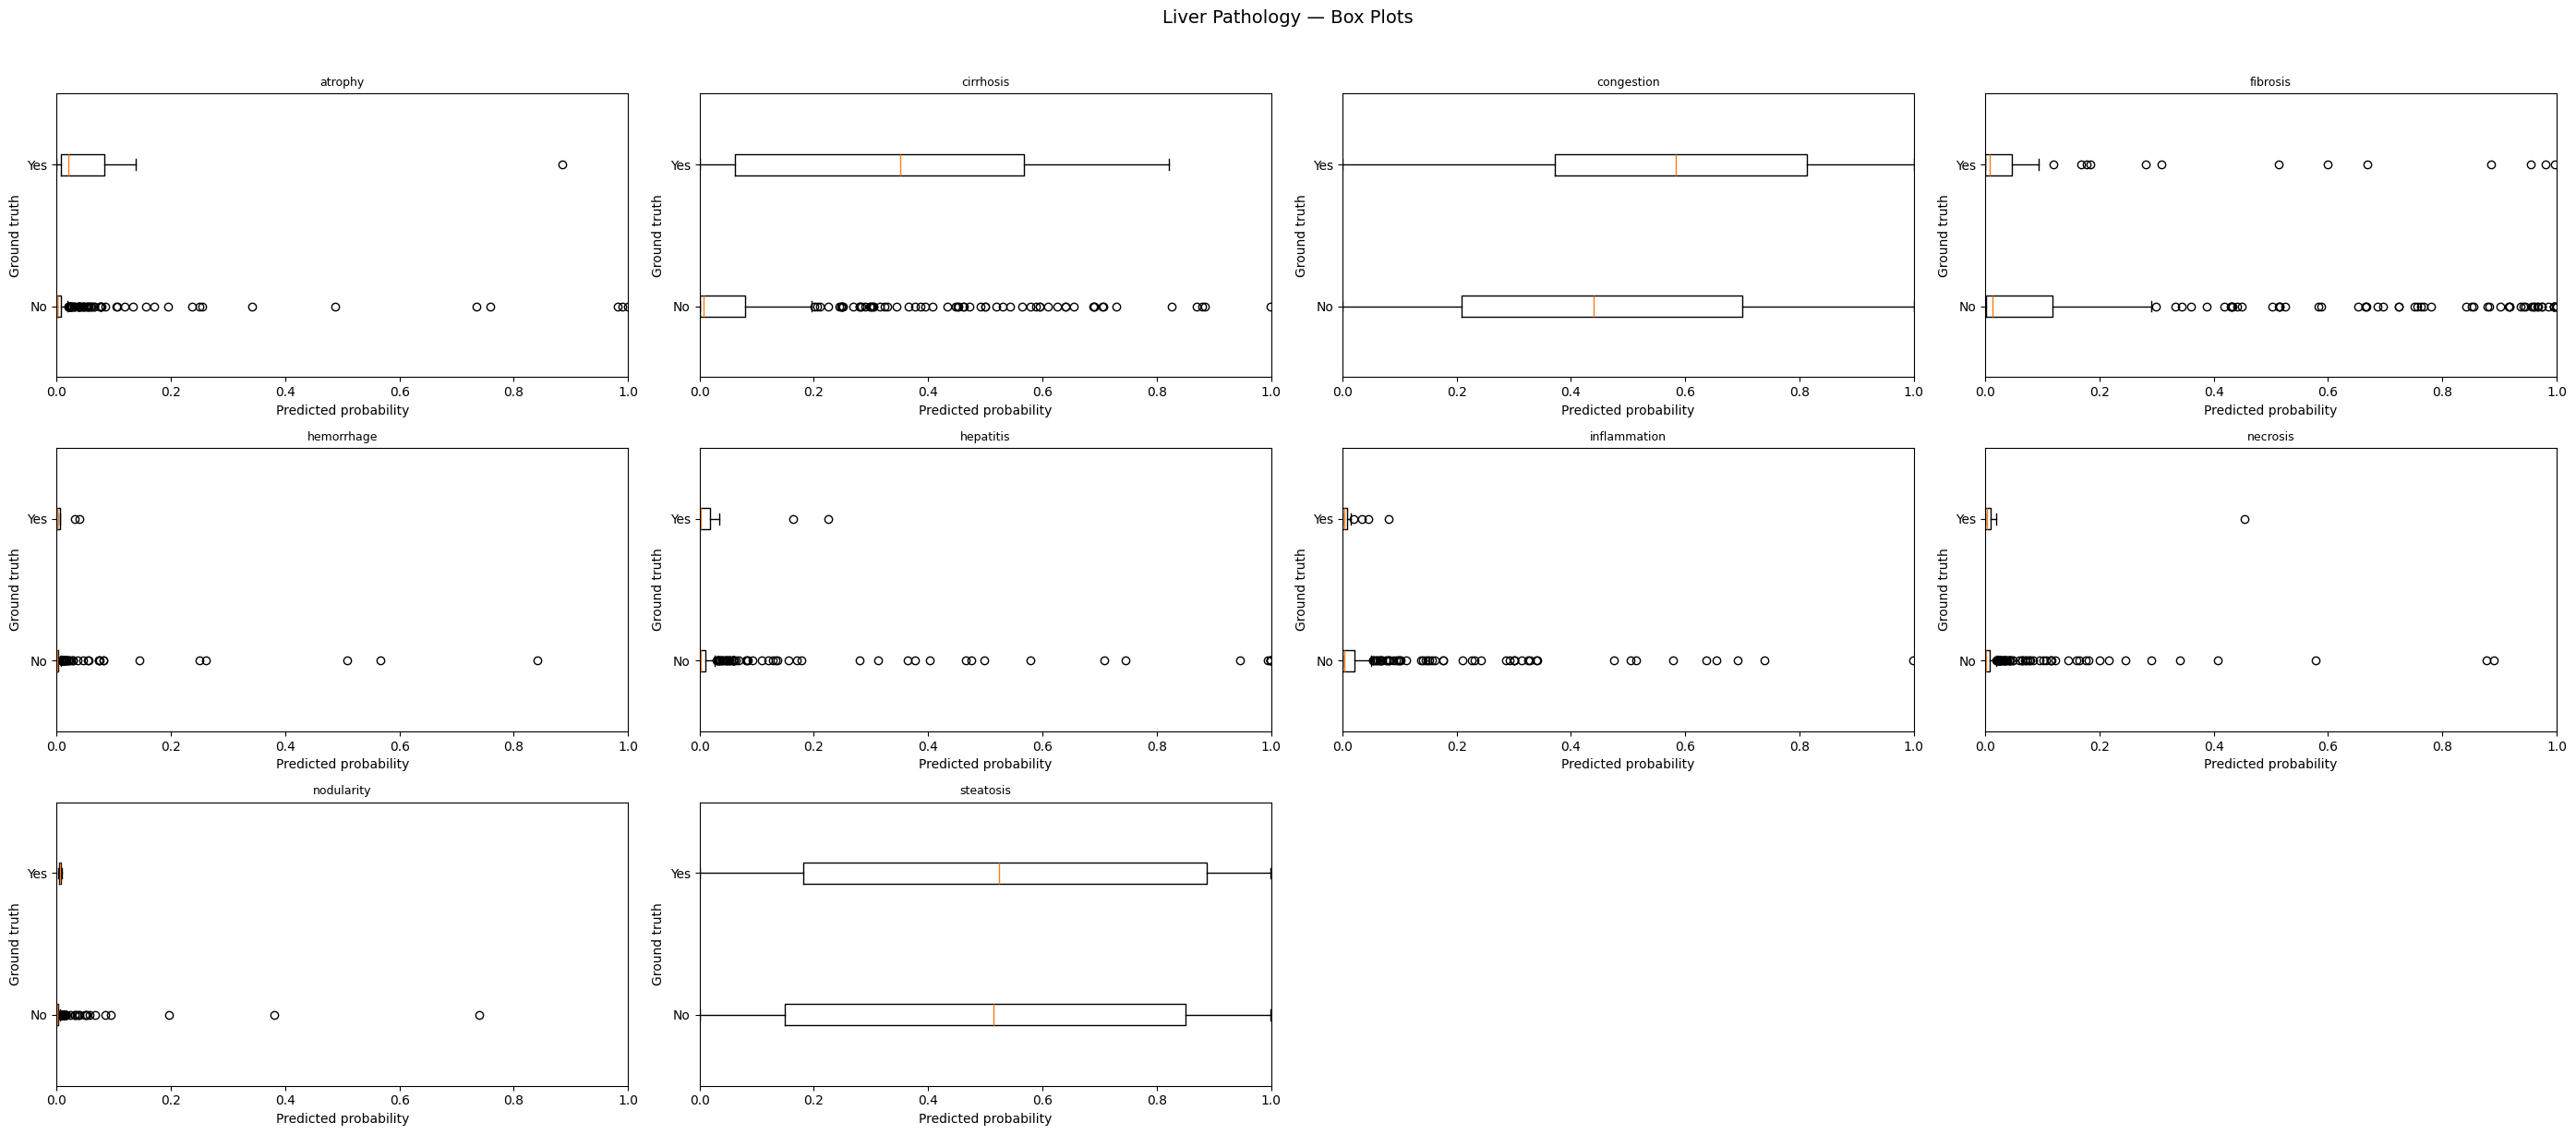

In [4]:
plot_roc_grid(model_results, suptitle="Liver Pathology — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_liver_multicategory.pdf")
plot_pr_grid(model_results, suptitle="Liver Pathology — Precision-Recall",
             save_path=Config.FIGURES_DIR / "pr_liver_multicategory.pdf")
plot_cm_grid(model_results, suptitle="Liver Pathology — Confusion Matrices (Youden's J)",
             save_path=Config.FIGURES_DIR / "cm_liver_multicategory.pdf")
plot_boxplot_grid(model_results, suptitle="Liver Pathology — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_liver_multicategory.pdf")